# 17_机器学习模型评估方法-F1 分数

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/sms.tsv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文咱们会聊聊**机器学习模型评估方法-F1 分数**\~

在机器学习中，尤其是**分类问题**（比如判断一封邮件是不是垃圾邮件），我们训练了一个模型后，得知道它表现好不好。

F1 分数就是一个非常重要的**评估标准**，它综合考虑了两个重要因素：

- **精确率（Precision）**：你说是的里面，真的是的有多少？
- **召回率（Recall）**：真正的是里，你说出来了多少？

**F1 分数就是一个平衡这两方面的综合评分。**

比如说在医院，如果一个模型精确率特别高但召回率特别低，那说明你很少误诊，但很多真正的病人你没发现。

而 F1 分数能帮你综合这两个指标，判断整体好不好。

### F1 分数的数学原理和公式推理

#### 1. 四个基础概念：混淆矩阵四项

在理解 F1 分数前，我们得先知道以下四个术语，它们来自模型预测结果和真实值的对比：

|  | 实际为正（Positive） | 实际为负（Negative） |
|-|-|-|
| **预测为正** | TP（真正） | FP（假正） |
| **预测为负** | FN（假负） | TN（真负） |

- **TP（True Positive）**：模型预测是正类，实际也是正类。
- **FP（False Positive）**：模型预测是正类，但实际是负类（冤枉了）。
- **FN（False Negative）**：模型预测是负类，但实际是正类（漏掉了）。
- **TN（True Negative）**：模型预测是负类，实际也是负类。

#### 2. 精确率（Precision）的公式

表示模型**说是的里面，有多少是真的**。


$$
\text{Precision} = \frac{TP}{TP + FP}
$$


如果你预测了 10 个癌症患者，其中 7 个是真的（TP），3 个是误诊（FP），那你的精确率是：


$$
\frac{7}{7 + 3} = 0.7
$$


#### 3. 召回率（Recall）的公式

表示**真正的是里面，有多少被你说出来了**。


$$
\text{Recall} = \frac{TP}{TP + FN}
$$


如果现实中有 12 个癌症患者，而你只找出了 7 个（TP），漏掉了 5 个（FN），你的召回率是：


$$
\frac{7}{7 + 5} = \frac{7}{12} ≈ 0.583
$$


### F1 分数的核心公式

#### 为什么要有 F1 分数？

如果一个模型只看精确率，不顾召回率，或者只顾召回率，忽视精确率，那评估不全面。我们需要一个**平衡这两个指标的指标**，这就是 F1 分数。

#### F1 分数公式：


$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$


这是**调和平均数**（不是普通平均数！）。

##### 举个例子：

如果精确率是 0.8，召回率是 0.6，那 F1 是：


$$
F1 = 2 \times \frac{0.8 \times 0.6}{0.8 + 0.6} = 2 \times \frac{0.48}{1.4} ≈ 0.686
$$


注意：调和平均强调「两个数都得高」，如果一个很低，F1 分数也会很低。

### 数学公式推导

#### 从精确率和召回率出发：

- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)

我们将这两个代入 F1 的公式：


$$
F1 = 2 \times \frac{\left(\frac{TP}{TP + FP}\right) \times \left(\frac{TP}{TP + FN}\right)}{\left(\frac{TP}{TP + FP}\right) + \left(\frac{TP}{TP + FN}\right)}
$$


这个公式看起来复杂，但它本质是：


$$
F1 = \frac{2TP}{2TP + FP + FN}
$$


这个是最简化的形式，直接体现了 TP、FP 和 FN 三者的关系。

### F1 分数的算法评估流程

**步骤 1：获得预测结果**

你有一组真实的标签（例如：是否是垃圾邮件），还有一组模型预测的标签。

**步骤 2：统计 TP、FP、FN、TN**

构建混淆矩阵，数出：

- 有多少真正（TP）
- 有多少假正（FP）
- 有多少假负（FN）

**步骤 3：计算精确率和召回率**

用上面两个公式：

- Precision = TP / (TP + FP)
- Recall = TP / (TP + FN)

**步骤 4：计算 F1 分数**


$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$


或者简化形式：


$$
F1 = \frac{2TP}{2TP + FP + FN}
$$


**步骤 5：分析结果**

- 如果 F1 分数接近 1，说明模型表现很好。
- 如果 F1 分数很低（比如 < 0.5），说明模型在某方面严重失衡。

## 完整案例

我们使用一个经典的文本分类问题作为实际案例：**垃圾邮件识别**。

这个问题属于**二分类问题**：判断一封邮件是“垃圾邮件（spam）”还是“正常邮件（ham）”。

<callout emoji="🏆">
数据集在公众号：深夜努力写Python，后台回复「数据集」既可获取\~
</callout>

这个场景很贴切 F1 分数的应用，因为：

- 垃圾邮件通常是少数类（**正类**），而正常邮件是多数类（**负类**）；
- 如果你把所有邮件都预测成正常的，准确率可能还挺高，但没啥意义；
- 所以需要综合考虑「预测准确性」和「漏掉垃圾邮件的严重性」，这正是 F1 分数能解决的！

F1 分数：0.9470

分类报告（Classification Report）:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.90      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



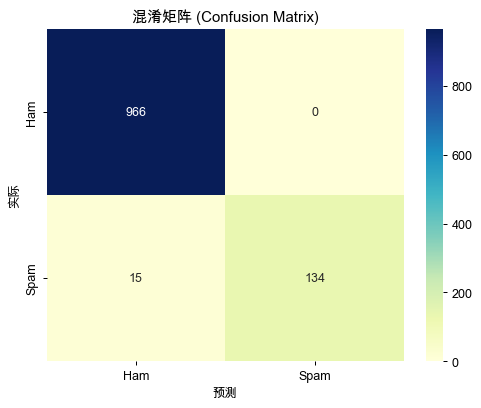

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, classification_report, confusion_matrix


# 1. 加载数据（UCI Spam）
url = DATA_DIR / 'sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# 2. 数据预处理
df['label'] = df['label'].map({'ham': 0, 'spam': 1})  # ham=0，spam=1

# 3. 文本向量化（TF-IDF）
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(df['message'])
y = df['label']

# 4. 划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. 建立模型并训练（使用朴素贝叶斯）
model = MultinomialNB()
model.fit(X_train, y_train)

# 6. 模型预测与评估
y_pred = model.predict(X_test)

# 7. 打印 F1 分数
f1 = f1_score(y_test, y_pred)
print(f"F1 分数：{f1:.4f}")

# 8. 分类报告
print("\n分类报告（Classification Report）:")
print(classification_report(y_test, y_pred))

# 9. 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu", xticklabels=["Ham", "Spam"], yticklabels=["Ham", "Spam"])
plt.title("混淆矩阵 (Confusion Matrix)")
plt.xlabel("预测")
plt.ylabel("实际")
plt.show()

**步骤 1：导入数据集**

数据源是一个公开的短信数据集，每行一条短信，包括标签和内容：

In [3]:
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

其中：

- `label` 是目标变量，有两个值：ham（正常）和 spam（垃圾）；
- `message` 是短信的内容。

**步骤 2：标签处理**

我们把标签转换成数字格式，便于机器学习模型处理：

In [4]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

- `0` 表示正常短信（负类）
- `1` 表示垃圾短信（正类）

**步骤 3：文本向量化（TF-IDF）**

自然语言中的词是文字，不能直接输入模型。我们用 TF-IDF 方法把每条短信转成数值向量。

In [5]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)

- 去除英文停用词（如 "the", "is"）
- 限制最大特征数为 3000，防止维度过高

TF-IDF 本质：词频 × 逆文档频率，强调有代表性的词。

**步骤 4：划分数据集**

我们把数据按 80/20 划分成训练集和测试集：

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

训练集用于学习，测试集用于检验。

**步骤 5：选择模型（朴素贝叶斯）**

文本分类问题，朴素贝叶斯是常见首选，尤其适合处理词频型特征：

In [7]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


模型学习词之间的联合概率，建立垃圾与非垃圾的概率模型。

**步骤 6：模型预测与评估**

In [8]:
y_pred = model.predict(X_test)

用模型预测测试集短信是否为垃圾。

**步骤 7：F1 分数评估**

In [9]:
f1 = f1_score(y_test, y_pred)

F1 分数越高，说明模型在“找准”与“找全”两个方面表现越好。

**步骤 8：分类报告**

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.90      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



包含精确率、召回率、F1 分数、支持度（样本数）。

输出：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.90      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115
```

可见：spam 类的 F1 分数为 0.90，说明分类表现良好，但还有提升空间。

**步骤 9：混淆矩阵可视化**

<Axes: >

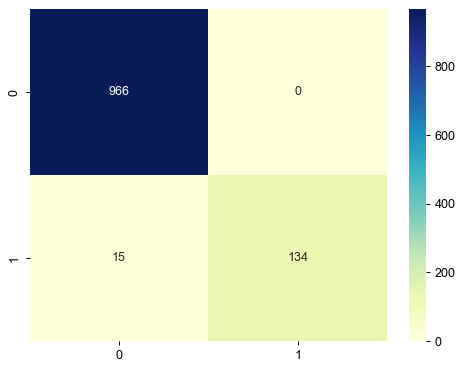

In [11]:
sns.heatmap(cm, annot=True, fmt='d', cmap="YlGnBu")

可以快速看到：

![原文参考图，当前结果见代码输出](attachments/img_012.png)

- 预测错的有多少？
- 哪一类误判更多？

结果：

|  | 预测ham | 预测spam |
|-|-|-|
| 实际ham | 966 | 0 |
| 实际spam | 15 | 134 |

我们看到，垃圾邮件漏掉了 18 封（FN），误判了 8 封正常邮件为垃圾（FP），这些对 F1 分数有重要影响。

### F1 分数的优缺点

**优点：**

1. **平衡评估两个维度**：F1 分数考虑了误判和漏判，不会偏向任何一方，在任务中更“公平”。
2. **适用于不平衡分类问题**：在 spam 分类、欺诈识别、疾病检测等场景下，正负样本分布极不均衡时，F1 分数仍能正确评估模型好坏。
3. **对极端错误敏感**：如果你的模型有严重的漏判或误判，F1 分数会迅速降低，警示你优化模型。
4. **更贴近实际场景关注点**：现实业务往往不只追求准确率，而是希望“尽量不漏掉关键类”，F1 分数正适用于此。

**缺点：**

1. **忽略真负类（TN）**：F1 不考虑真正类（即正常预测正确的“非垃圾邮件”），所以它不能反映总体准确度。
2. **无法单独分析 Precision 和 Recall 的失衡原因**：F1 分数是综合值，如果低了，我们不知道是精确率低，还是召回率低，必须单独分析。
3. **对业务优先级无法调整**：某些场景下我们可能更关注 Recall（不要漏判），但 F1 默认两者同等重要，无法权衡业务优先级。
4. **不适用于多类分类的直接比较**：F1 分数在多分类时需要加权平均，计算方式变复杂，解释性也下降。

### F1 分数适用场景讨论：什么时候是首选？

**适用情况：**

1. **类别不平衡**的分类任务（比如 spam 检测、欺诈检测、癌症识别）；
2. **错误代价不均衡**时（如漏判一个癌症患者比误诊更严重）；
3. **对模型鲁棒性要求高**，需要防止模型只关注准确率却忽略实际应用价值；
4. **任务目标是综合考察模型对正类检测能力**，而不仅仅是整体准确。

**不适用情况：**

- 当样本非常均衡、误判和漏判成本相当时，**accuracy（准确率）或ROC-AUC**可能更简单直观；
- 当你希望显式地优先优化 precision 或 recall 时，**F1 分数可能会掩盖细节**；
- 当你有丰富负类分析需求时，F1 会忽略真负类信息。

通过实际输出的混淆矩阵、分类报告，我们可以看到，F1 分数能很好反映模型的**分类准确性与全面性**；

能警惕我们对**小类漏判**问题的忽视，在不平衡分类问题中，远比“准确率”更可靠。